In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

For 20 hits:
- SFARI Gene scores
- Acidic/S/P/Q rich? 


# 20 HIts

## SFARI Gene scores

In [26]:
hits = [
    "ARX", "CASZ1", "CAMTA2", "ERG", "HIVEP3", "IKZF1", "KDM5B", 
    "KLF16", "KLF7", "MEIS2", "MTF1", "MYT1L", "NR1D1", "NKX2-2", 
    "OTX1", "PAX5", "PAX6", "PITX1", "TFE3", "YY1"
]
len(hits)

20

In [27]:
SFARI_gene = pd.read_csv("../data/SFARI-Gene_genes_01-23-2023release_03-21-2023export.csv")
SFARI_gene

,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
0,9,ABAT,4-aminobutyrate aminotransferase,ENSG00000183044,16,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,7
1,9,ABCA10,"ATP-binding cassette, sub-family A (ABC1), mem...",ENSG00000154263,17,Rare Single Gene Mutation,2.0,0,NaN,2
2,9,ABCA13,ATP binding cassette subfamily A member 13,ENSG00000179869,7,"Rare Single Gene Mutation, Functional",2.0,0,NaN,10
3,9,ABCA7,"ATP-binding cassette, sub-family A (ABC1), mem...",ENSG00000064687,19,Rare Single Gene Mutation,2.0,0,NaN,5
4,9,ABL2,"ABL proto-oncogene 2, non-receptor tyrosine ki...",ENSG00000143322,1,"Rare Single Gene Mutation, Functional",3.0,0,NaN,10
...,...,...,...,...,...,...,...,...,...,...
1113,9,ZNF774,Zinc finger protein 774,ENSG00000196391,15,Rare Single Gene Mutation,2.0,0,NaN,4
1114,9,ZNF804A,Zinc finger protein 804A,ENSG00000170396,2,"Rare Single Gene Mutation, Genetic Association...",2.0,0,NaN,16
1115,9,ZNF827,Zinc finger protein 827,ENSG00000151612,4,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,3
1116,9,ZSWIM6,zinc finger SWIM-type containing 6,ENSG00000130449,5,"Rare Single Gene Mutation, Syndromic, Genetic ...",NaN,1,NaN,6


In [28]:
len(SFARI_gene[SFARI_gene["gene-symbol"].isin(hits)])

20

In [29]:
SFARI_gene_hits = SFARI_gene[SFARI_gene["gene-symbol"].isin(hits)]
SFARI_gene_hits.to_csv("../data/sfari_gene_dbd_hits.csv")
SFARI_gene_hits

,status,gene-symbol,gene-name,ensembl-id,chromosome,genetic-category,gene-score,syndromic,eagle,number-of-reports
62,9,ARX,aristaless related homeobox,ENSG00000004848,X,"Rare Single Gene Mutation, Syndromic",1.0,1,13.80,24
135,9,CASZ1,castor zinc finger 1,ENSG00000130940,1,Rare Single Gene Mutation,1.0,0,9.55,6
153,9,CAMTA2,calmodulin binding transcription activator 2,ENSG00000108509,17,"Rare Single Gene Mutation, Syndromic",1.0,0,NaN,3
399,9,ERG,"ERG, ETS transcription factor",ENSG00000157554,21,Genetic Association,2.0,0,NaN,1
429,9,HIVEP3,human immunodeficiency virus type I enhancer b...,ENSG00000127124,1,"Rare Single Gene Mutation, Genetic Association",2.0,0,NaN,8
456,9,IKZF1,IKAROS family zinc finger 1,ENSG00000185811,7,Rare Single Gene Mutation,3.0,0,NaN,6
501,9,KDM5B,Lysine (K)-specific demethylase 5B,ENSG00000117139,1,"Rare Single Gene Mutation, Syndromic, Functional",1.0,0,2.80,19
513,9,KLF16,Kruppel like factor 16,ENSG00000129911,19,Rare Single Gene Mutation,2.0,0,NaN,1
514,9,KLF7,Kruppel like factor 7,ENSG00000118263,2,"Rare Single Gene Mutation, Functional",3.0,0,NaN,13
581,9,MEIS2,Meis homeobox 2,ENSG00000134138,15,"Rare Single Gene Mutation, Syndromic",1.0,1,7.50,12


In [30]:
SFARI_gene_hits["syndromic"].value_counts()

syndromic
0    15
1     5
Name: count, dtype: int64

In [31]:
SFARI_gene_hits["gene-score"].value_counts()

gene-score
1.0    8
2.0    7
3.0    3
Name: count, dtype: int64

Text(0, 0.5, 'Count')

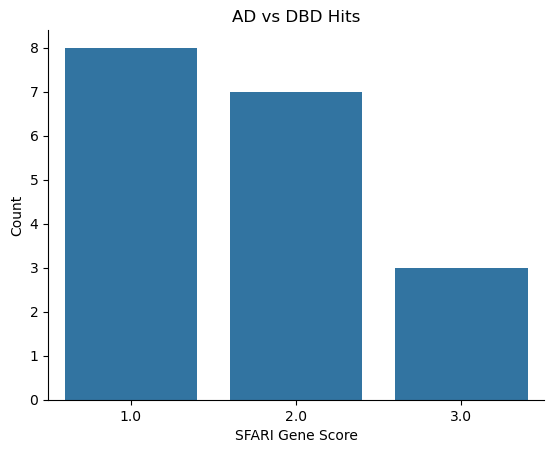

In [32]:
sns.barplot(SFARI_gene_hits["gene-score"].value_counts())
sns.despine()
plt.title("AD vs DBD Hits")
plt.xlabel("SFARI Gene Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

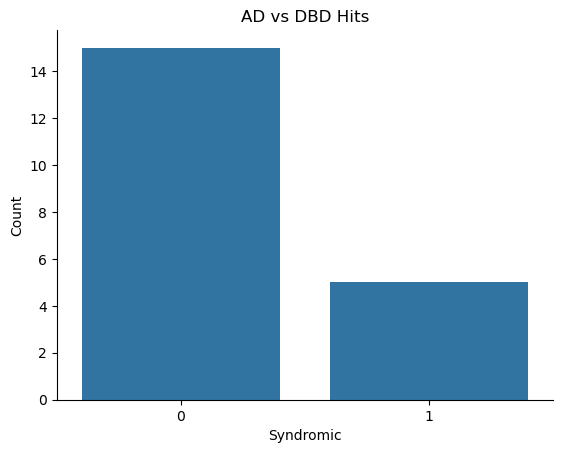

In [33]:
sns.barplot(SFARI_gene_hits["syndromic"].value_counts())
sns.despine()
plt.title("AD vs DBD Hits")
plt.xlabel("Syndromic")
plt.ylabel("Count")

X chromosome?

In [44]:
known_ADs = pd.read_csv("../output/known_ADs_considering_isoforms_and_canonical.csv")
hit_ADs = known_ADs[known_ADs["Gene"].isin(hits)]
hit_ADs = hit_ADs[~hit_ADs["uniprotID"].str.contains("-")]
hit_uniprotIDs = hit_ADs[["Gene", "uniprotID"]].drop_duplicates()
hit_uniprotIDs

,Gene,uniprotID
22,ARX,Q96QS3
48,CAMTA2,O94983
50,CASZ1,Q86V15
125,ERG,P11308
234,HIVEP3,Q5T1R4
267,IKZF1,Q13422
291,KDM5B,Q9UGL1
297,KLF16,Q9BXK1
303,KLF7,O75840
333,MEIS2,O14770


In [49]:
TF_tbl = pd.read_csv("../soto_analysis/outputs/all_TFs_table_proteins.txt", sep = "\t")
hit_tbl = pd.merge(hit_uniprotIDs, TF_tbl, how = 'left')
hit_tbl

,Gene,uniprotID,Unnamed: 0,1,2,ENSG,ENST,DBD_coords,AD_coords,RD_coords,Bif_coords,length
0,ARX,Q96QS3,567,NaN,NaN,NaN,ENST00000379044,329-385,472-562,NaN,NaN,1
1,CAMTA2,O94983,822,NaN,NaN,NaN,ENST00000348066,37-149,"285-468,472-581",NaN,NaN,1
2,CASZ1,Q86V15,1243,NaN,NaN,NaN,ENST00000377022,"489-514,550-574,609-634,667-691,1030-1054,1181...",31-185,NaN,NaN,1
3,ERG,P11308,861,NaN,NaN,NaN,ENST00000288319,312-391,"433-479,118-261",NaN,NaN,1
4,HIVEP3,Q5T1R4,1167,NaN,NaN,NaN,ENST00000372583,"192-214,220-242,1754-1776,1782-1806",211-1074,NaN,NaN,1
5,IKZF1,Q13422,1084,NaN,NaN,NaN,ENST00000331340,"117-139,145-167,173-195,201-224",284-365,NaN,NaN,1
6,KDM5B,Q9UGL1,1518,NaN,NaN,NaN,ENST00000367265,99-183,1302-1391,NaN,NaN,1
7,KLF16,Q9BXK1,605,NaN,NaN,NaN,ENST00000250916,"127-151,157-181,187-209",209-252,NaN,NaN,1
8,KLF7,O75840,819,NaN,NaN,NaN,ENST00000309446,"219-243,249-273,279-301",2-101,NaN,NaN,1
9,MEIS2,O14770,765,NaN,NaN,NaN,ENST00000561208,277-334,340-477,NaN,NaN,1


In [61]:
for i in hit_tbl.index:
    ENST_df = pd.read_csv("../soto_analysis/outputs/mutations/cds_bed_format/" + hit_tbl["ENST"].iloc[i], sep = "\t", header = None)
    if ENST_df[0].iloc[0] == "X":
        print(hit_tbl["Gene"].iloc[i] + "\t" + str(ENST_df[0].iloc[0]))

ARX	X
TFE3	X


In [62]:
for i in hit_tbl.index:
    ENST_df = pd.read_csv("../soto_analysis/outputs/mutations/cds_bed_format/" + hit_tbl["ENST"].iloc[i], sep = "\t", header = None)
    print(hit_tbl["Gene"].iloc[i] + "\t" + str(ENST_df[0].iloc[0]))

ARX	X
CAMTA2	17
CASZ1	1
ERG	21
HIVEP3	1
IKZF1	7
KDM5B	1
KLF16	19
KLF7	2
MEIS2	15
MTF1	1
MYT1L	2
NKX2-2	20
NR1D1	17
OTX1	2
PAX5	9
PAX6	11
PITX1	5
TFE3	X
YY1	14
